# Where and at what size are bicycles actually detected?

Where and at what size are bicycles actually detected?

Two passes over a folder of video stills (assumed to be in temporal order
when sorted by filename):

  PASS A - per-detection dump.
      Every detection above a low confidence floor is written out with its
      centre, size and score. Feeds the position heatmap and the
      confidence-vs-size curve.

  PASS B - tracking.
      ByteTrack at the same low floor links detections across frames. Each
      track is one physical object seen across a range of sizes. Within a
      track the object is known to be present in every frame between first
      and last sighting, so:
          P(detect at conf T | size bin) =
              (# track-frames with conf >= T) / (# track-frames)
      Frames where the tracker lost the object entirely are recovered by
      linear interpolation between the surrounding sightings and counted as
      misses. This is a real recall curve obtained without hand labels.

Outputs (OUTPUT_DIR):
  detections_raw.csv        one row per detection
  tracks.csv                one row per track-frame (incl. interpolated)
  detectability_by_size.csv recall vs size bin, per confidence threshold
  size_gate_sweep.csv       count MAE vs (min box height, conf) if GT given
  plots/*.png               heatmap, size histogram, recall curves

## Setup

Run once per Colab session. Skip the Drive mount if your data is local.

In [1]:
!pip install -q -U ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.3/45.3 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 56.2 MB/s eta 0:00:00


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# Copying to local scratch is much faster than reading from Drive.
!cp -r "/content/drive/MyDrive/datasets/Computer_Vision_Project/test_1" \
       "/content/local_video_stills"

!nvidia-smi --query-gpu=name,memory.total --format=csv

name, memory.total [MiB]
Tesla T4, 15360 MiB


In [4]:
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from ultralytics import YOLO

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


## Configuration

In [5]:
IMAGE_DIR = "/content/local_video_stills"
OUTPUT_DIR = "/content/drive/MyDrive/datasets/detectability"
WEIGHTS = "yolo26m.pt"          # use your strongest model here

TARGET_CLASS = "bicycle"        # analyse one class at a time
CAPTURE_CONF = 0.05             # low floor: we want the weak detections too
IOU_NMS = 0.7
IMGSZ = 640
DEVICE = "cuda"
HALF = True

TRACKER = "bytetrack.yaml"      # or "botsort.yaml"
MAX_GAP_FILL = 10               # interpolate gaps up to N frames long

# Size bins on box height in pixels (height is more stable than area for
# ground-plane objects: it scales ~linearly with distance).
HEIGHT_BINS = [0, 15, 25, 35, 50, 70, 100, 150, 250, 10_000]
CONF_LEVELS = [0.10, 0.15, 0.25, 0.35, 0.50]

HEATMAP_GRID = (12, 20)         # rows x cols over the image

# Optional: ground-truth counts, enables the size-gate sweep
LABELS_CSV = "/content/drive/MyDrive/datasets/results2_reviewed.csv"             # e.g. "/content/drive/MyDrive/datasets/labels.csv"
FILENAME_COL = "filename"
GT_COL = "bicycle"
GATE_HEIGHTS = [0, 10, 15, 20, 25, 30, 40, 50, 70]

VALID_EXT = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

In [6]:
def image_list():
    paths = sorted(p for p in Path(IMAGE_DIR).iterdir() if p.suffix.lower() in VALID_EXT)
    if not paths:
        raise RuntimeError(f"No images in {IMAGE_DIR}")
    return paths

In [7]:
def class_id(model):
    for k, v in model.names.items():
        if v == TARGET_CLASS:
            return k
    raise ValueError(f"{TARGET_CLASS!r} not in model classes")

## PASS A - per-detection dump

In [8]:
def pass_a(paths):
    model = YOLO(WEIGHTS)
    cid = class_id(model)
    rows = []
    for i, p in enumerate(paths):
        r = model.predict(str(p), device=DEVICE, imgsz=IMGSZ, half=HALF,
                          conf=CAPTURE_CONF, iou=IOU_NMS, verbose=False)[0]
        H, W = r.orig_shape
        if r.boxes is None or not len(r.boxes):
            continue
        cls = r.boxes.cls.cpu().numpy().astype(int)
        conf = r.boxes.conf.cpu().numpy()
        xyxy = r.boxes.xyxy.cpu().numpy()
        for c, s, (x1, y1, x2, y2) in zip(cls, conf, xyxy):
            if c != cid:
                continue
            w, h = x2 - x1, y2 - y1
            rows.append({
                "frame": i, "filename": p.name, "img_w": W, "img_h": H,
                "conf": float(s),
                "cx": float((x1 + x2) / 2), "cy": float((y1 + y2) / 2),
                "w": float(w), "h": float(h), "area": float(w * h),
                "cx_norm": float((x1 + x2) / 2 / W), "cy_norm": float((y1 + y2) / 2 / H),
                "area_frac": float(w * h / (W * H)),
            })
    return pd.DataFrame(rows)

## PASS B - tracking + gap interpolation

In [9]:
def pass_b(paths):
    model = YOLO(WEIGHTS)
    cid = class_id(model)
    obs = defaultdict(dict)   # track_id -> {frame: record}

    for i, p in enumerate(paths):
        r = model.track(str(p), persist=True, tracker=TRACKER, device=DEVICE,
                        imgsz=IMGSZ, half=HALF, conf=CAPTURE_CONF,
                        iou=IOU_NMS, verbose=False)[0]
        if r.boxes is None or r.boxes.id is None:
            continue
        H, W = r.orig_shape
        ids = r.boxes.id.cpu().numpy().astype(int)
        cls = r.boxes.cls.cpu().numpy().astype(int)
        conf = r.boxes.conf.cpu().numpy()
        xyxy = r.boxes.xyxy.cpu().numpy()
        for tid, c, s, (x1, y1, x2, y2) in zip(ids, cls, conf, xyxy):
            if c != cid:
                continue
            obs[tid][i] = {
                "track_id": int(tid), "frame": i, "filename": p.name,
                "img_w": W, "img_h": H, "conf": float(s),
                "cx": float((x1 + x2) / 2), "cy": float((y1 + y2) / 2),
                "w": float(x2 - x1), "h": float(y2 - y1),
                "interpolated": False,
            }

    # fill gaps inside each track
    rows = []
    for tid, frames in obs.items():
        keys = sorted(frames)
        if len(keys) < 2:
            rows.extend(frames.values())
            continue
        for a, b in zip(keys, keys[1:]):
            rows.append(frames[a])
            gap = b - a - 1
            if 0 < gap <= MAX_GAP_FILL:
                fa, fb = frames[a], frames[b]
                for k in range(1, gap + 1):
                    t = k / (gap + 1)
                    rows.append({
                        "track_id": tid, "frame": a + k, "filename": None,
                        "img_w": fa["img_w"], "img_h": fa["img_h"],
                        "conf": 0.0,                      # a genuine miss
                        "cx": fa["cx"] + t * (fb["cx"] - fa["cx"]),
                        "cy": fa["cy"] + t * (fb["cy"] - fa["cy"]),
                        "w": fa["w"] + t * (fb["w"] - fa["w"]),
                        "h": fa["h"] + t * (fb["h"] - fa["h"]),
                        "interpolated": True,
                    })
        rows.append(frames[keys[-1]])

    df = pd.DataFrame(rows)
    if not df.empty:
        df["area"] = df["w"] * df["h"]
        df["cy_norm"] = df["cy"] / df["img_h"]
        df["cx_norm"] = df["cx"] / df["img_w"]
    return df

## Detectability curve

In [10]:
def detectability(tracks):
    tracks = tracks.copy()
    tracks["h_bin"] = pd.cut(tracks["h"], HEIGHT_BINS, right=False)
    out = []
    for hb, g in tracks.groupby("h_bin", observed=True):
        row = {"height_bin": str(hb), "n_track_frames": len(g),
               "median_conf": float(g["conf"].median())}
        for t in CONF_LEVELS:
            row[f"recall@{t:.2f}"] = float((g["conf"] >= t).mean())
        out.append(row)
    return pd.DataFrame(out)

## Size-gate sweep against ground-truth counts

In [11]:
def gate_sweep(dets, paths):
    gt = pd.read_csv(LABELS_CSV)
    gt["_key"] = gt[FILENAME_COL].astype(str).map(lambda s: Path(s).name.lower())
    gt = gt.set_index("_key")[GT_COL].fillna(0).astype(int)

    names = [p.name for p in paths if p.name.lower() in gt.index]
    truth = np.array([gt.loc[n.lower()] for n in names])
    idx = {n: i for i, n in enumerate(names)}

    rows = []
    for min_h in GATE_HEIGHTS:
        for t in CONF_LEVELS:
            pred = np.zeros(len(names), dtype=int)
            sel = dets[(dets["h"] >= min_h) & (dets["conf"] >= t)]
            for n, c in sel["filename"].value_counts().items():
                if n in idx:
                    pred[idx[n]] = c
            err = pred - truth
            rows.append({
                "min_box_height_px": min_h, "conf": t,
                "mae": float(np.abs(err).mean()),
                "bias": float(err.mean()),
                "exact_match": float((err == 0).mean()),
                "total_pred": int(pred.sum()), "total_true": int(truth.sum()),
            })
    return pd.DataFrame(rows).sort_values("mae")

## Plots

In [12]:
def make_plots(dets, tracks, det_curve, outdir):
    pdir = outdir / "plots"
    pdir.mkdir(exist_ok=True)

    if not dets.empty:
        rows, cols = HEATMAP_GRID
        hm, _, _ = np.histogram2d(
            dets["cy_norm"], dets["cx_norm"], bins=[rows, cols],
            range=[[0, 1], [0, 1]])
        plt.figure(figsize=(9, 5))
        plt.imshow(hm, aspect="auto", origin="upper", extent=[0, 1, 1, 0])
        plt.colorbar(label="detections")
        plt.title(f"Where {TARGET_CLASS} is detected (normalised image coords)")
        plt.xlabel("x"); plt.ylabel("y")
        plt.tight_layout(); plt.savefig(pdir / "position_heatmap.png", dpi=130); plt.close()

        plt.figure(figsize=(8, 4.5))
        plt.hist(dets["h"], bins=60)
        plt.xlabel("box height (px)"); plt.ylabel("count")
        plt.title("Detected box height distribution")
        plt.tight_layout(); plt.savefig(pdir / "height_hist.png", dpi=130); plt.close()

        plt.figure(figsize=(8, 4.5))
        plt.scatter(dets["h"], dets["conf"], s=6, alpha=0.25)
        plt.xlabel("box height (px)"); plt.ylabel("confidence")
        plt.title("Confidence vs apparent size")
        plt.tight_layout(); plt.savefig(pdir / "conf_vs_size.png", dpi=130); plt.close()

    if not det_curve.empty:
        plt.figure(figsize=(8, 4.5))
        x = np.arange(len(det_curve))
        for t in CONF_LEVELS:
            plt.plot(x, det_curve[f"recall@{t:.2f}"], marker="o", label=f"conf {t:.2f}")
        plt.xticks(x, det_curve["height_bin"], rotation=45, ha="right")
        plt.ylabel("detection rate"); plt.xlabel("box height bin (px)")
        plt.title("Detectability vs apparent size (from tracks)")
        plt.legend(); plt.grid(alpha=0.3)
        plt.tight_layout(); plt.savefig(pdir / "detectability.png", dpi=130); plt.close()


# =============================================================

In [13]:
def main():
    out = Path(OUTPUT_DIR); out.mkdir(parents=True, exist_ok=True)
    paths = image_list()
    print(f"{len(paths)} frames from {IMAGE_DIR}\n")

    print("Pass A: per-detection dump...")
    dets = pass_a(paths)
    dets.to_csv(out / "detections_raw.csv", index=False)
    print(f"  {len(dets)} {TARGET_CLASS} detections above conf {CAPTURE_CONF}")
    if not dets.empty:
        print(f"  box height: median {dets['h'].median():.0f} px, "
              f"p10 {dets['h'].quantile(.1):.0f}, p90 {dets['h'].quantile(.9):.0f}")

    print("\nPass B: tracking...")
    tracks = pass_b(paths)
    tracks.to_csv(out / "tracks.csv", index=False)
    if not tracks.empty:
        n_tracks = tracks["track_id"].nunique()
        n_interp = int(tracks["interpolated"].sum())
        print(f"  {n_tracks} tracks, {len(tracks)} track-frames "
              f"({n_interp} recovered by interpolation)")

        curve = detectability(tracks)
        curve.to_csv(out / "detectability_by_size.csv", index=False)
        print("\n" + curve.to_string(index=False))
    else:
        curve = pd.DataFrame()
        print("  no tracks found")

    if LABELS_CSV:
        print("\nSize-gate sweep against ground truth...")
        sweep = gate_sweep(dets, paths)
        sweep.to_csv(out / "size_gate_sweep.csv", index=False)
        print(sweep.head(10).to_string(index=False))

    make_plots(dets, tracks, curve, out)
    print(f"\nWritten to {out}")

## Run

In [14]:
main()

1001 frames from /content/local_video_stills

Pass A: per-detection dump...
WARNING ⚠️ 'half' is deprecated and will be removed in the future. Use 'quantize' instead.
WARNING ⚠️ 'half' is deprecated and will be removed in the future. Use 'quantize' instead.
WARNING ⚠️ 'half' is deprecated and will be removed in the future. Use 'quantize' instead.
WARNING ⚠️ 'half' is deprecated and will be removed in the future. Use 'quantize' instead.
WARNING ⚠️ 'half' is deprecated and will be removed in the future. Use 'quantize' instead.
WARNING ⚠️ 'half' is deprecated and will be removed in the future. Use 'quantize' instead.
WARNING ⚠️ 'half' is deprecated and will be removed in the future. Use 'quantize' instead.
WARNING ⚠️ 'half' is deprecated and will be removed in the future. Use 'quantize' instead.
WARNING ⚠️ 'half' is deprecated and will be removed in the future. Use 'quantize' instead.
WARNING ⚠️ 'half' is deprecated and will be removed in the future. Use 'quantize' instead.
WARNING ⚠️ 'ha

## Inspect the results

The plots are written to `plots/` but also render inline below.

position_heatmap


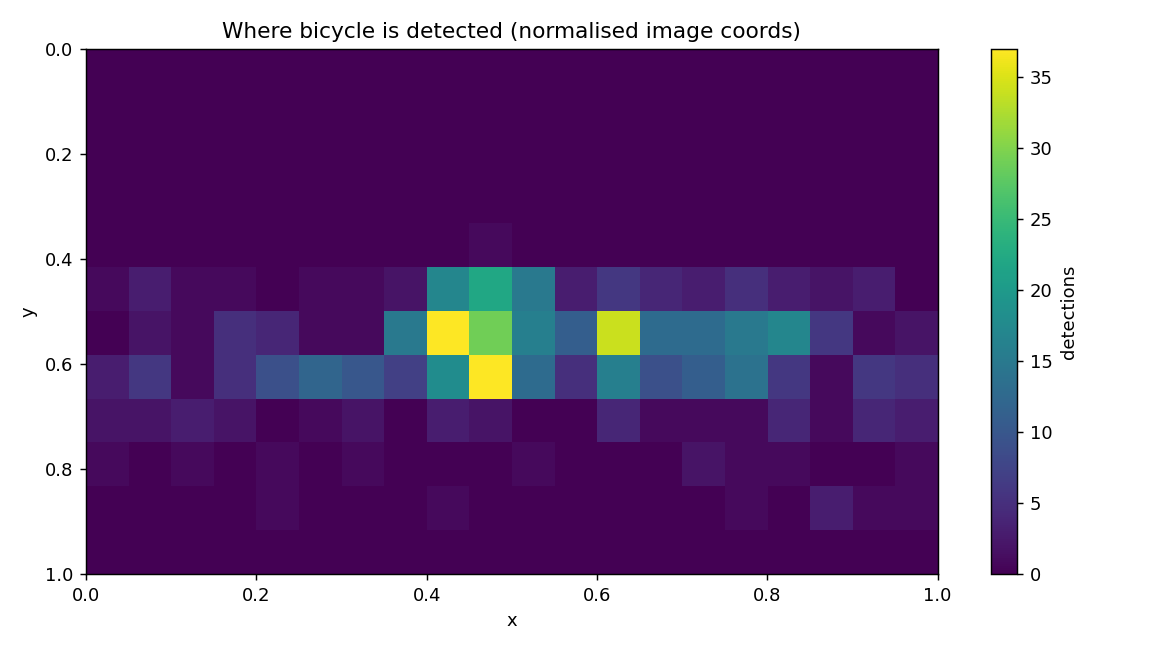

height_hist


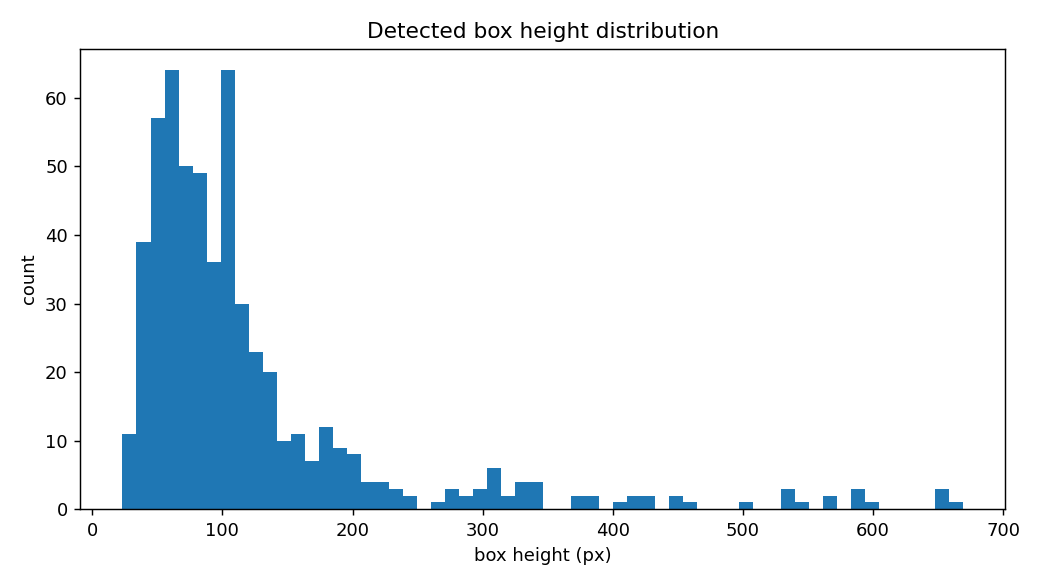

conf_vs_size


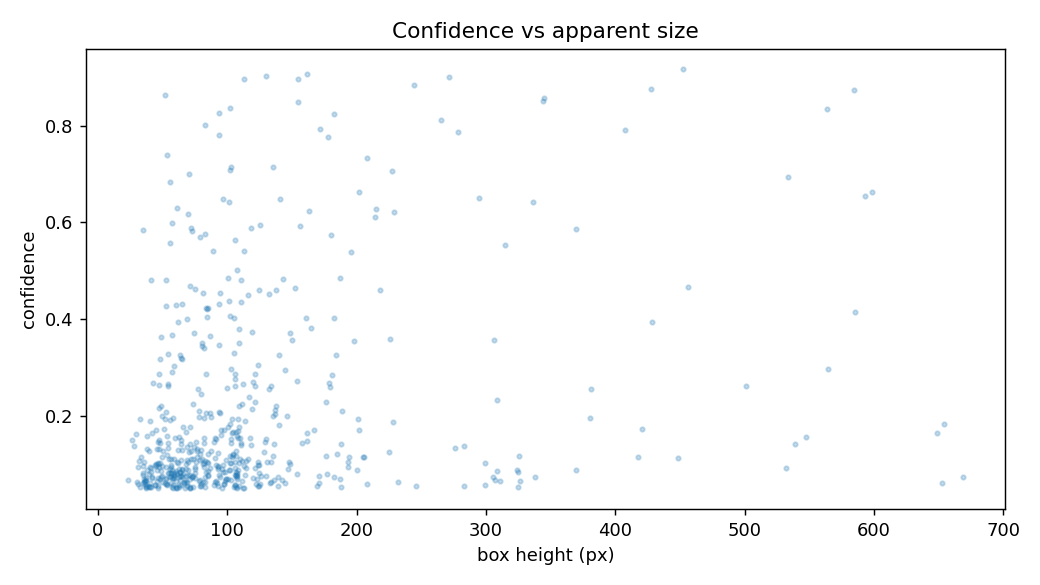

detectability


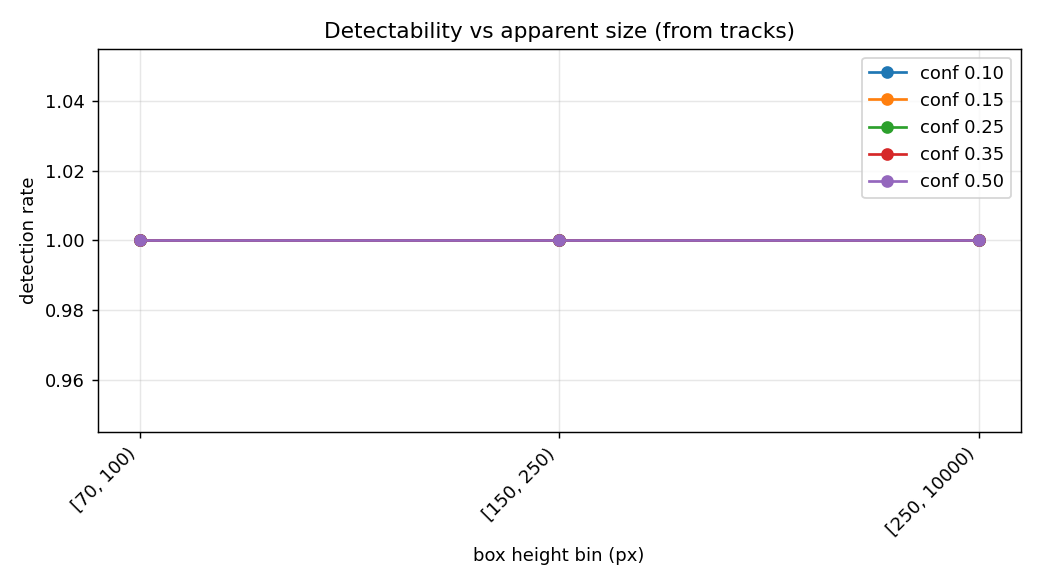

In [15]:
from IPython.display import Image, display
for name in ['position_heatmap', 'height_hist',
             'conf_vs_size', 'detectability']:
    p = f'{OUTPUT_DIR}/plots/{name}.png'
    if Path(p).exists():
        print(name)
        display(Image(p))

In [16]:
# Recall vs apparent size, straight from the tracks.
pd.read_csv(f'{OUTPUT_DIR}/detectability_by_size.csv')

,height_bin,n_track_frames,median_conf,recall@0.10,recall@0.15,recall@0.25,recall@0.35,recall@0.50
0,"[70, 100)",1,0.588867,1.0,1.0,1.0,1.0,1.0
1,"[150, 250)",2,0.791016,1.0,1.0,1.0,1.0,1.0
2,"[250, 10000)",1,0.654785,1.0,1.0,1.0,1.0,1.0


### The decisive table

With `LABELS_CSV` set, this shows count MAE for every combination of minimum box height and confidence. If the best row beats your ungated baseline by a wide margin, the bias was an annotation-convention problem and no retraining is needed.

In [17]:
gate = pd.read_csv(f'{OUTPUT_DIR}/size_gate_sweep.csv')
display(gate.head(10))

pivot = gate.pivot(index='min_box_height_px', columns='conf', values='mae')
fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(pivot.values, aspect='auto', cmap='viridis_r')
ax.set_xticks(range(len(pivot.columns)),
              [f'{c:.2f}' for c in pivot.columns])
ax.set_yticks(range(len(pivot.index)), pivot.index)
ax.set_xlabel('confidence'); ax.set_ylabel('min box height (px)')
ax.set_title('Count MAE by gate setting (darker = better)')
fig.colorbar(im, label='MAE')
plt.tight_layout()

,min_box_height_px,conf,mae,bias,exact_match,total_pred,total_true
0,0,0.25,0.126873,-0.100899,0.896104,154,255
1,10,0.25,0.126873,-0.100899,0.896104,154,255
2,15,0.25,0.126873,-0.100899,0.896104,154,255
3,20,0.25,0.126873,-0.100899,0.896104,154,255
4,25,0.25,0.126873,-0.100899,0.896104,154,255
5,30,0.25,0.126873,-0.100899,0.896104,154,255
6,40,0.25,0.127872,-0.101898,0.895105,153,255
7,50,0.25,0.131868,-0.107892,0.893107,147,255
8,70,0.25,0.149850,-0.129870,0.883117,125,255
9,25,0.35,0.154845,-0.140859,0.888112,114,255


### Applying the chosen gate

Once you have a winning `(min_height, conf)` pair, this is the whole fix — recompute counts from the cached detections and drop it into the benchmark pipeline.

In [18]:
MIN_H, CONF = 25, 0.25   # <- set from the table above

dets = pd.read_csv(f'{OUTPUT_DIR}/detections_raw.csv')
gated = dets[(dets['h'] >= MIN_H) & (dets['conf'] >= CONF)]
counts = gated.groupby('filename').size().rename('bicycle_pred')
counts.head(10)

,bicycle_pred
filename,
DJI_0392_frame_00005.jpg,4
DJI_0392_frame_00006.jpg,1
DJI_0392_frame_00007.jpg,1
DJI_0392_frame_00010.jpg,1
DJI_0392_frame_00011.jpg,1
DJI_0392_frame_00012.jpg,1
DJI_0392_frame_00016.jpg,2
DJI_0392_frame_00017.jpg,1
DJI_0392_frame_00018.jpg,3
